# Supplementary Figure 4: Cholesterol Trajectory Analysis — HSI + SFC

**Description:**
Merges HSI (`.tif` → `tifffile.imread + phasor_from_signal`) and SFC (`.fcs` → `fcsparser` + `phasor_from_signal`)

into a single phasor analysis notebook.

All condition strings are normalised to `'DOPC 0%'`, `'DPPC 25%'`, `'DOPC DPPC 33%'`, etc.

A `Platform` column (`'HSI'` / `'SFC'`) is preserved throughout.

Masking via PNG files is applied for HSI (image) data; SFC FCS data are already pre-gated.

Defines:

- `normalize_condition_string` — converts both HSI (`DOPC 0 Chol`) and

SFC (`DOPC Chol 0%`) filenames to canonical `DOPC 0%` form.

- `build_condition(lipid, chol)` — builds a canonical condition string.

- Masking helpers (PNG masks → applied to HSI image data).

- `load_hsi_data` — reads `.lsm`/`.tif`/`.tiff` files with `tifffile.imread` + `phasor_from_signal` (with median filter and threshold).

- `load_sfc_data` — reads `.fcs` files with `fcsparser` (spectral V-columns) + `phasor_from_signal`.

Uses `os.listdir` (non-recursive) to avoid accidentally reading sub-folders like `duplicado/`.

## 1. Import Dependencies

This section imports all required libraries for loading data, phasor computation, and plotting.

In [17]:
import os, re
import cv2
import tifffile
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import fcsparser
from phasorpy.component import phasor_component_fit
from phasorpy.filter import phasor_filter_median, phasor_threshold
from phasorpy.phasor import phasor_center, phasor_from_signal
from phasorpy.plot import PhasorPlot

# Condition normalisation
_PAT_HSI = re.compile(r'^(DOPC(?:\s+DPPC)?|DPPC)\s+(\d+)\s+Chol', re.I)
_PAT_SFC = re.compile(r'^(DOPC(?:\s+DPPC)?|DPPC)\s+Chol\s+(\d+)%', re.I)

def normalize_condition_string(raw):
    # Normalise HSI or SFC condition name -> canonical 'LIPID N%'.
    raw = re.sub(r'_\d+$', '', raw).strip()
    for pat in (_PAT_HSI, _PAT_SFC):
        m = pat.match(raw)
        if m:
            return f"{m.group(1).upper().strip()} {m.group(2)}%"
    return raw.strip()

def build_condition(lipid, chol):
    return f"{lipid} {chol}%"

def get_chol_pct(cond):
    m = re.search(r'(\d+)%', cond)
    return int(m.group(1)) if m else 0

def get_lipid_group(cond):
    if cond.startswith("DOPC DPPC"): return "DOPC DPPC"
    if cond.startswith("DOPC"):      return "DOPC"
    if cond.startswith("DPPC"):      return "DPPC"
    return "Other"

def sort_key(cond):
    p = {"DOPC": 1, "DPPC": 2, "DOPC DPPC": 3}.get(get_lipid_group(cond), 4)
    return p, get_chol_pct(cond)

COLORS = {"DOPC": "navy", "DPPC": "darkred", "DOPC DPPC": "forestgreen"}

def style_axes(ax, ts=18, ls=20):
    ax.set_facecolor("white")
    ax.tick_params(axis="both", which="major", labelsize=ts)
    ax.set_xlabel(ax.get_xlabel(), fontsize=ls)
    ax.set_ylabel(ax.get_ylabel(), fontsize=ls)
    ax.set_title("")

# Masking helpers (for HSI image data)
def _find_mask(file_path, data_paths, mask_roots):
    if not data_paths or not mask_roots: return None
    file_abs = os.path.abspath(file_path)
    base = os.path.splitext(os.path.basename(file_path))[0]
    local = os.path.join(os.path.dirname(file_abs), "mask", f"mask_{base}.png")
    if os.path.isfile(local): return local
    for dr, mr in zip(data_paths, mask_roots):
        dr_abs = os.path.abspath(dr)
        try: under = os.path.commonpath([file_abs, dr_abs]) == dr_abs
        except ValueError: under = False
        if not under: continue
        rel = os.path.relpath(os.path.dirname(file_abs), dr_abs)
        cands = []
        if rel != ".": cands.append(os.path.join(mr, rel, f"mask_{base}.png"))
        cands.append(os.path.join(mr, f"mask_{base}.png"))
        for c in cands:
            if os.path.isfile(c): return c
    return None

def _load_mask(file_path, data_paths, mask_roots, shape):
    mf = _find_mask(file_path, data_paths, mask_roots)
    if mf is None: return None
    img = cv2.imread(mf, cv2.IMREAD_GRAYSCALE)
    if img is None: return None
    h, w = shape[0], shape[1]
    if img.shape != (h, w):
        img = cv2.resize(img, (w, h), interpolation=cv2.INTER_NEAREST)
    return img > 0

def _apply_mask(arr, mask):
    if mask is None: return arr
    a = np.asarray(arr).copy()
    a[~mask] = np.nan
    return a

# HSI loader (tifffile + phasor_from_signal)
def load_hsi_data(data_paths, mask_paths=None, axis=0, mean_min=3, include_source=False):
    # Read .lsm/.tif/.tiff files with tifffile.imread + phasor_from_signal.
    if mask_paths is None:
        mask_roots = [os.path.join(dp, "mask") for dp in data_paths]
    else:
        mask_roots = mask_paths

    exts = ("lsm", "tif", "tiff")
    rows = {"Mean": [], "Real": [], "Imag": [], "Condition": [], "Platform": []}
    if include_source:
        rows["Experiment"] = []

    for dp in data_paths:
        if not os.path.exists(dp):
            print(f"  [HSI] path not found: {dp}"); continue
        for fn in sorted(os.listdir(dp)):
            if fn.lower().rsplit(".", 1)[-1] not in exts: continue
            fp = os.path.join(dp, fn)
            if not os.path.isfile(fp): continue
            base = fn
            for e in ("tiff", "tif", "lsm"):
                if base.lower().endswith("." + e):
                    base = base[:-(len(e)+1)]; break
            cond = normalize_condition_string(base)
            try:
                signal = tifffile.imread(fp)
                mean, real, imag = phasor_from_signal(signal, harmonic=1, axis=axis)
                mean, real, imag = phasor_filter_median(mean, real, imag, size=3, repeat=3)
                mean, real, imag = phasor_threshold(mean, real, imag, mean_min=mean_min)
            except Exception as exc:
                print(f"  [HSI] skip {fn}: {exc}"); continue

            mask = _load_mask(fp, data_paths, mask_roots, np.asarray(mean).shape)
            if mask is not None:
                mean = _apply_mask(mean, mask)
                real = _apply_mask(real, mask)
                imag = _apply_mask(imag, mask)

            mf = np.asarray(mean).flatten()
            rf = np.asarray(real).flatten()
            ig = np.asarray(imag).flatten()
            v  = np.isfinite(mf) & np.isfinite(rf) & np.isfinite(ig)
            rows["Mean"].extend(mf[v]); rows["Real"].extend(rf[v])
            rows["Imag"].extend(ig[v])
            rows["Condition"].extend([cond] * v.sum())
            rows["Platform"].extend(["HSI"] * v.sum())
            if include_source:
                rows["Experiment"].extend([dp] * v.sum())

    df = pd.DataFrame(rows)
    print(f"  [HSI] {df.shape[0]} pixels, {df['Condition'].nunique()} conditions")
    return df

# SFC loader
def _extract_spectral_signal(file_path):
    # Read FCS file and return sorted spectral signal array (V-columns only).
    _, data = fcsparser.parse(file_path, reformat_meta=True)
    spectral_cols = sorted(
        [col for col in data.columns if "V" in col],
        key=lambda x: int(x.split("-")[0][1:]),
    )
    return data[spectral_cols].to_numpy()

def load_sfc_data(data_paths, harmonics=None, include_source=False):
    # Read .fcs files using fcsparser + phasor_from_signal (non-recursive).
    if harmonics is None:
        harmonics = [1]
    harmonics = [harmonics] if isinstance(harmonics, int) else harmonics
    single = len(harmonics) == 1

    rows = {"Mean": [], "Real": [], "Imag": [], "Condition": [], "Platform": []}
    if include_source:
        rows["Experiment"] = []

    for dp in data_paths:
        if not os.path.exists(dp):
            print(f"  [SFC] path not found: {dp}"); continue
        for fn in sorted(os.listdir(dp)):   # non-recursive - skip duplicado/ etc.
            if not fn.lower().endswith(".fcs"): continue
            fp = os.path.join(dp, fn)
            base = fn[:-4]
            cond = normalize_condition_string(base)
            try:
                signal = _extract_spectral_signal(fp)
                if single:
                    mean, real, imag = phasor_from_signal(signal, harmonic=harmonics[0])
                    real = np.atleast_2d(real)
                    imag = np.atleast_2d(imag)
                else:
                    mean, real, imag = phasor_from_signal(signal, harmonic=harmonics)
            except Exception as exc:
                print(f"  [SFC] skip {fn}: {exc}"); continue

            mf = mean.flatten()
            rf = [r.flatten() for r in real]
            ig = [i.flatten() for i in imag]
            valid = np.isfinite(mf)
            for hi in range(len(harmonics)):
                valid &= np.isfinite(rf[hi]) & np.isfinite(ig[hi])

            if valid.sum() == 0: continue
            rows["Mean"].extend(mf[valid])
            rows["Real"].extend(rf[0][valid])   # harmonic 1 -> 'Real' column
            rows["Imag"].extend(ig[0][valid])
            rows["Condition"].extend([cond] * valid.sum())
            rows["Platform"].extend(["SFC"] * valid.sum())
            if include_source:
                rows["Experiment"].extend([dp] * valid.sum())

    df = pd.DataFrame(rows)
    print(f"  [SFC] {df.shape[0]} events, {df['Condition'].nunique()} conditions")
    return df

print("Utilities loaded.")

Utilities loaded.


## Configuration

Set paths for **each platform independently**.
- `paths_hsi` / `paths_sfc`: list of folder paths.
- `mask_paths_hsi`: optional explicit mask folders for HSI (or `None` → `<path>/mask/`).
- `dopc_intermediate_chol`: the intermediate cholesterol % in the DOPC trajectory (typically 33 or 25).


In [18]:
# ---- HSI ----
paths_hsi = [
    "/Users/bruno/Documents/UBA/phSFC/phSFC_analisis/Datos/Micro confocal 880/2026-02-12 Liposomas copy",
    "/Users/bruno/Documents/UBA/phSFC/phSFC_analisis/Datos/Micro confocal 880/2025-07-16 liposomas laurdan colesterol",
]
mask_paths_hsi = None   # None → look for <path>/mask/mask_<filename>.png

# ---- SFC ----
paths_sfc = [
    "/Users/bruno/Documents/UBA/phSFC/phSFC_analisis/Datos/Citometro Aurora/2025-06-11 Liposomas citometria colesterol laurdan/pre-gated 13-06-25",
    "/Users/bruno/Documents/UBA/phSFC/phSFC_analisis/Datos/Citometro Aurora/2025-07-16 Liposomas Laurdan Colesterol/pre-gated 16-07-25",
]

# ---- Shared ----
dopc_intermediate_chol = 33   # intermediate % used in DOPC trajectory (33)

print(f"HSI paths: {len(paths_hsi)}")
print(f"SFC paths: {len(paths_sfc)}")


HSI paths: 2
SFC paths: 2


## Load phasor data from both platforms

Reads files from each platform's folders, normalises condition strings, and
concatenates into a single `df_phasor` DataFrame with columns
`Mean`, `Real`, `Imag`, `Condition`, `Platform`, `Cholesterol`.

- **HSI**: `.lsm` / `.tif` / `.tiff` images → `tifffile.imread` + `phasor_from_signal` (with median filter and threshold); PNG masks applied if present. Loading is non-recursive.
- **SFC**: `.fcs` files → `fcsparser` (spectral V-columns) + `phasor_from_signal`; pre-gated, no image mask needed.
  FCS loading is non-recursive so sub-folders like `duplicado/` are ignored.


In [19]:
print("Loading HSI data ...")
df_hsi = load_hsi_data(paths_hsi, mask_paths_hsi, include_source=True)

print("Loading SFC data ...")
df_sfc = load_sfc_data(paths_sfc, harmonics=[1], include_source=True)

df_phasor = pd.concat([df_hsi, df_sfc], ignore_index=True)
df_phasor["Cholesterol"] = df_phasor["Condition"].apply(get_chol_pct)

print(f"\nCombined: {df_phasor.shape[0]} rows")
print(f"Platforms : {sorted(df_phasor['Platform'].unique())}")
print(f"Conditions: {sorted(df_phasor['Condition'].unique(), key=sort_key)}")
print(f"Chol %    : {sorted(df_phasor['Cholesterol'].unique())}")
if "Experiment" in df_phasor.columns:
    print(f"Experiments: {df_phasor['Experiment'].nunique()} source paths")

Loading HSI data ...
  [HSI] 1263328 pixels, 9 conditions
Loading SFC data ...
  [SFC] 154354 events, 9 conditions

Combined: 1417682 rows
Platforms : ['HSI', 'SFC']
Conditions: ['DOPC 0%', 'DOPC 33%', 'DOPC 50%', 'DPPC 0%', 'DPPC 33%', 'DPPC 50%', 'DOPC DPPC 0%', 'DOPC DPPC 33%', 'DOPC DPPC 50%']
Chol %    : [np.int64(0), np.int64(33), np.int64(50)]
Experiments: 4 source paths


## Per-cholesterol phasor plots

One plot per cholesterol % per platform (HSI and SFC displayed separately).
DOPC DPPC mix → 2-D histogram; pure components → median center + label.


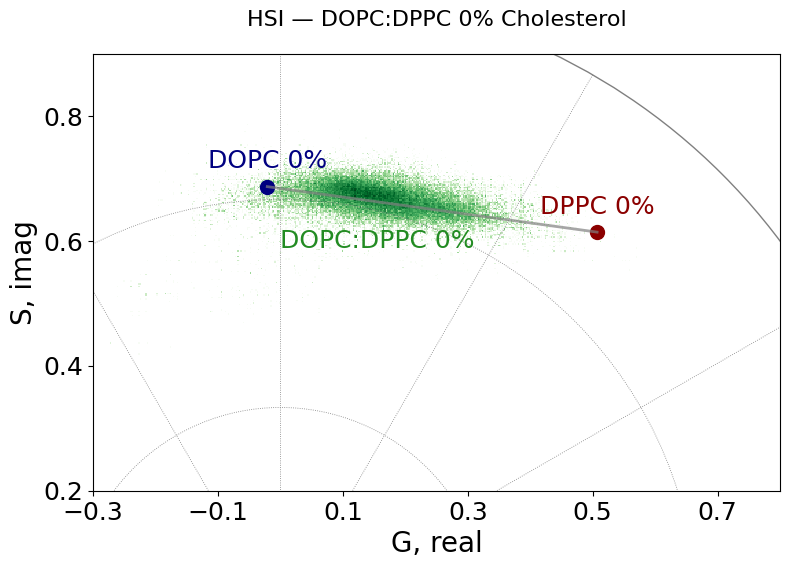

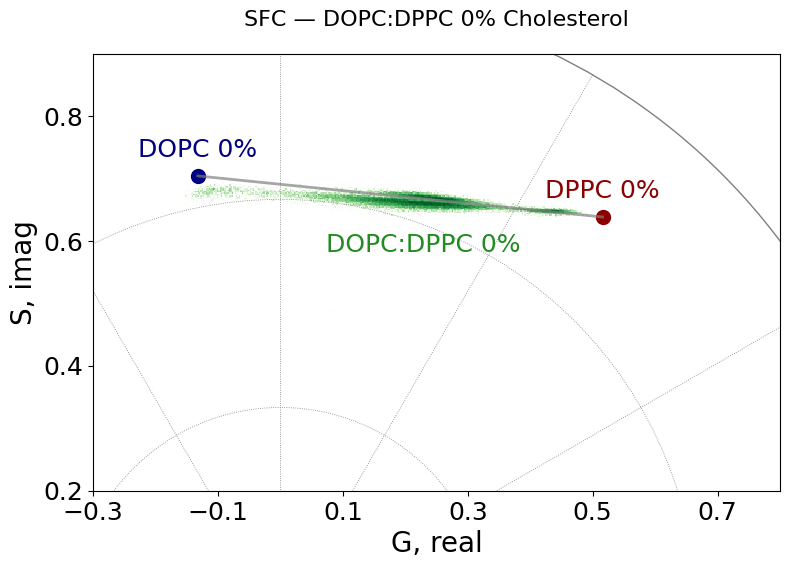

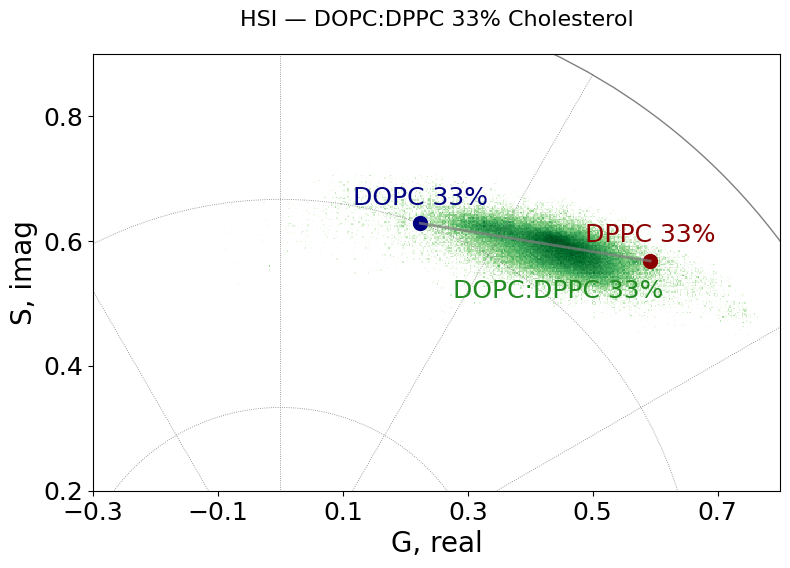

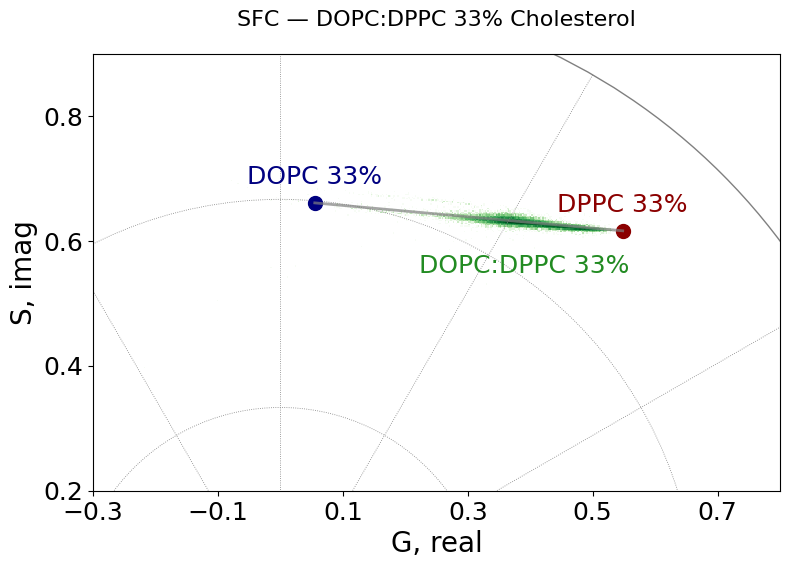

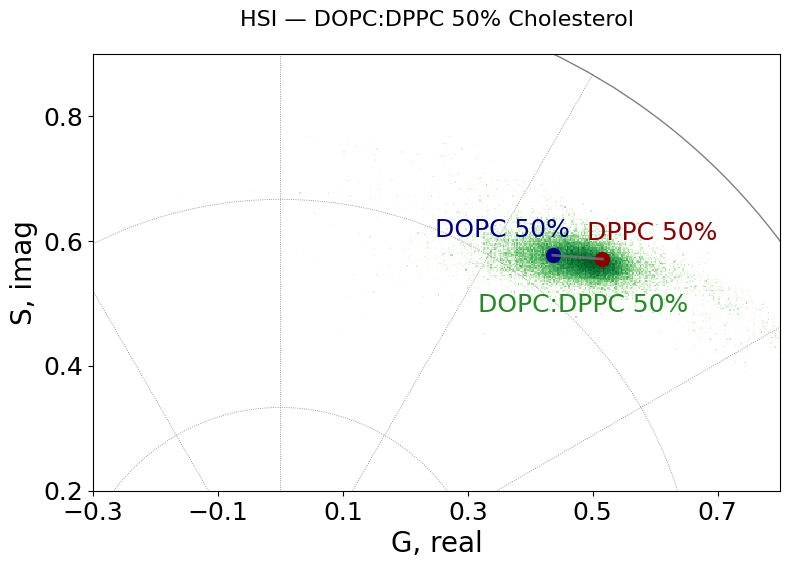

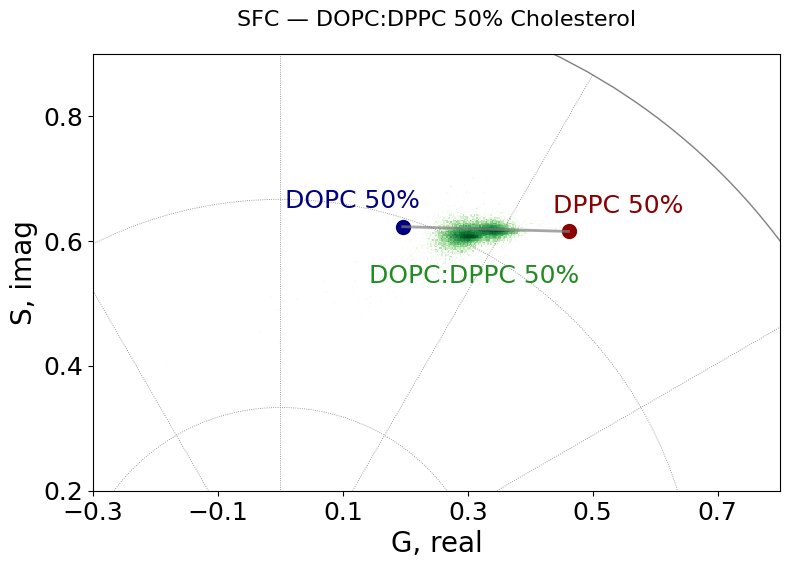

In [ ]:
for chol in sorted(df_phasor["Cholesterol"].dropna().unique()):
    for platform in ["HSI", "SFC"]:
        chol_df = df_phasor[(df_phasor["Cholesterol"] == chol) & (df_phasor["Platform"] == platform)]
        if chol_df.empty: continue
        dopc_c, dppc_c, mix_c = (build_condition(l, chol) for l in ("DOPC", "DPPC", "DOPC DPPC"))
        avail = chol_df["Condition"].unique()
        if not all(c in avail for c in [dopc_c, dppc_c, mix_c]):
            print(f"Skipping {chol}% [{platform}] – missing conditions"); continue

        fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")
        
        style_axes(ax)
        pp = PhasorPlot(allquadrants=True, ax=ax, xlim=(-0.3, 0.8), ylim=(0.3, 0.9))
        ax.set_title(f"{platform} — DOPC:DPPC {chol}% Cholesterol", fontsize=16, pad=20)
        ax.set_xticks(np.arange(-0.3, 0.9, 0.2))
        ax.set_yticks(np.arange(0.2, 1.0, 0.2))
        centers = {}
        for cond, grp in [(dopc_c,"DOPC"),(dppc_c,"DPPC"),(mix_c,"DOPC DPPC")]:
            cdf = chol_df[chol_df["Condition"] == cond]
            if cdf.empty: continue
            col = COLORS[grp]
            ctr = phasor_center(cdf["Mean"].values, cdf["Real"].values, cdf["Imag"].values, method="median")
            centers[grp] = ctr
            label = cond.replace("DOPC DPPC", "DOPC:DPPC")
            if grp == "DOPC DPPC":
                pp.hist2d(cdf["Real"].values, cdf["Imag"].values, cmap="Greens", bins=500)
                ax.text(ctr[1], ctr[2] - 0.08, label, fontsize=18, ha="center", color=col)
            elif chol == 50:
                if grp == "DOPC":
                    ax.plot(ctr[1], ctr[2], "o", color=col, markersize=10)
                    ax.text(ctr[1] - 0.08, ctr[2] + 0.03, label, fontsize=18, ha="center", color=col)
                else:  # DPPC
                    ax.plot(ctr[1], ctr[2], "o", color=col, markersize=10)
                    ax.text(ctr[1] + 0.08, ctr[2] + 0.03, label, fontsize=18, ha="center", color=col)
            else:
                ax.plot(ctr[1], ctr[2], "o", color=col, markersize=10)
                ax.text(ctr[1], ctr[2] + 0.03, label, fontsize=18, ha="center", color=col)
        if "DOPC" in centers and "DPPC" in centers:
            dc, pc = centers["DOPC"], centers["DPPC"]
            ax.plot([dc[1],pc[1]], [dc[2],pc[2]], linewidth=2, alpha=0.7, color="gray")
        # output_path = 'supp_figure_4'
        # os.makedirs(output_path, exist_ok=True)
        # plt.savefig(os.path.join(output_path, f"phasor_trajectory_{platform.lower()}_{chol}%.png"), dpi=600)
        plt.tight_layout(); plt.show(); plt.close()

## DOPC cholesterol trajectory plots

Trajectory between DOPC 0% and DOPC 50% with 2-D histogram for the intermediate %
and the theoretical linear-mixing point. Shown separately for HSI and SFC.


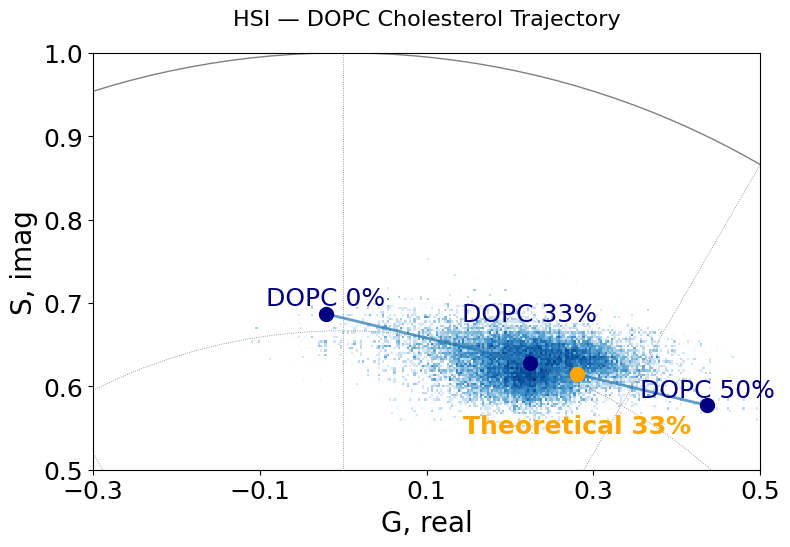

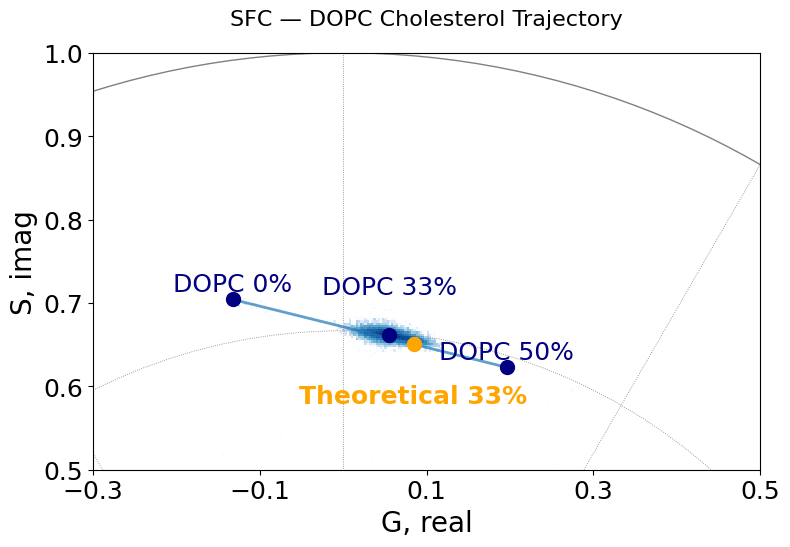

In [ ]:
for platform in ["HSI", "SFC"]:
    df_plat = df_phasor[df_phasor["Platform"] == platform]
    d0  = df_plat[df_plat["Condition"] == build_condition("DOPC", 0)]
    d50 = df_plat[df_plat["Condition"] == build_condition("DOPC", 50)]
    dm  = df_plat[df_plat["Condition"] == build_condition("DOPC", dopc_intermediate_chol)]
    if d0.empty or d50.empty or dm.empty:
        print(f"Missing DOPC conditions for trajectory plot [{platform}]."); continue

    fig, ax = plt.subplots(figsize=(8, 6), facecolor="white")
    
    style_axes(ax)
    pp = PhasorPlot(allquadrants=True, ax=ax, xlim=(-0.3, 0.5), ylim=(0.5, 1))
    ax.set_title(f"{platform} — DOPC Cholesterol Trajectory", fontsize=16, pad=20)
    ax.set_xticks(np.arange(-0.3, 0.6, 0.2))
    ax.set_yticks(np.arange(0.5, 1.01, 0.1))
    c0  = phasor_center(d0["Mean"].values,  d0["Real"].values,  d0["Imag"].values,  method="median")
    c50 = phasor_center(d50["Mean"].values, d50["Real"].values, d50["Imag"].values, method="median")
    cm  = phasor_center(dm["Mean"].values,  dm["Real"].values,  dm["Imag"].values,  method="median")

    pp.hist2d(dm["Real"].values, dm["Imag"].values, cmap="Blues", bins=300)
    ax.plot([c0[1],c50[1]], [c0[2],c50[2]], linewidth=2, alpha=0.7)
    for ctr, lbl, dy in [(c0,"DOPC 0%",+0.01),(c50,"DOPC 50%",+0.01),(cm,f"DOPC {dopc_intermediate_chol}%",+0.05)]:
        ax.plot(ctr[1], ctr[2], "o", color="navy", markersize=10)
        ax.text(ctr[1], ctr[2]+dy, lbl, fontsize=18, ha="center", color="navy")

    t = dopc_intermediate_chol / 50.0
    mr, mi = c0[1]*(1-t)+c50[1]*t, c0[2]*(1-t)+c50[2]*t
    ax.plot(mr, mi, "o", color="orange", markersize=10)
    ax.text(mr, mi-0.07, f"Theoretical {dopc_intermediate_chol}%",
            fontsize=18, ha="center", color="orange", fontweight="bold")
    # output_path = 'supp_figure_4'
    # os.makedirs(output_path, exist_ok=True)
    # plt.savefig(os.path.join(output_path, f"DOPC_trajectory_{platform.lower()}_{dopc_intermediate_chol}%.png"), dpi=600)
    plt.tight_layout(); plt.show(); plt.close()

In [22]:
# ---- Output configuration for component-analysis CSVs ----
# Set this to your preferred output folder
component_csv_output_path = "/Users/bruno/Documents/UBA/phSFC/phSFC_analisis/Exported Plots/Fractions plots/supp_figure4_component_analysis"
os.makedirs(component_csv_output_path, exist_ok=True)

# Reuse already-loaded data when available (fast path). If missing source metadata,
# reload once with include_source=True.
if "df_phasor" in globals() and "Experiment" in df_phasor.columns:
    df_src = df_phasor.copy()
else:
    print("Experiment column not found in df_phasor. Reloading data once with source metadata...")
    df_hsi_src = load_hsi_data(paths_hsi, mask_paths_hsi, include_source=True)
    df_sfc_src = load_sfc_data(paths_sfc, harmonics=[1], include_source=True)
    df_src = pd.concat([df_hsi_src, df_sfc_src], ignore_index=True)


def compute_component_fraction(df_src, platform, target_condition, comp1_condition, comp2_condition):
    """Compute fraction of component 1 for all points in target_condition."""
    dpf = df_src[df_src["Platform"] == platform]

    c1_df = dpf[dpf["Condition"] == comp1_condition]
    c2_df = dpf[dpf["Condition"] == comp2_condition]
    tgt_df = dpf[dpf["Condition"] == target_condition]

    if c1_df.empty or c2_df.empty or tgt_df.empty:
        print(
            f"  [{platform}] skip {target_condition}: missing one of "
            f"({comp1_condition}, {comp2_condition}, {target_condition})"
        )
        return pd.DataFrame()

    c1 = phasor_center(
        c1_df["Mean"].values,
        c1_df["Real"].values,
        c1_df["Imag"].values,
        method="median",
    )
    c2 = phasor_center(
        c2_df["Mean"].values,
        c2_df["Real"].values,
        c2_df["Imag"].values,
        method="median",
    )

    mean_zero = np.zeros_like(tgt_df["Real"].values)
    fractions = phasor_component_fit(
        mean_zero,
        tgt_df["Real"].values,
        tgt_df["Imag"].values,
        [c1[1], c2[1]],
        [c1[2], c2[2]],
    )[0]

    # Build experiment labels from source paths so each source experiment has
    # a distinct replicate (Rep1, Rep2, ...), shared across both platforms.
    source_exp = tgt_df["Experiment"].astype(str)
    unique_source = list(pd.unique(source_exp))
    rep_map = {src: f"Rep{i+1}" for i, src in enumerate(unique_source)}

    out = pd.DataFrame(
        {
            "Experiment": source_exp.map(rep_map).values,
            "Source_Experiment": source_exp.values,
            "Condition": tgt_df["Condition"].values,
            "Fraction_Component1": fractions,
            "Cholesterol": tgt_df["Condition"].apply(get_chol_pct).values,
            "Platform": tgt_df["Platform"].values,
        }
    )
    return out


print(f"Rows available for fraction analysis: {len(df_src)}")

analyses = [
    {
        "name": "mixture_0_chol_fraction",
        "target": build_condition("DOPC DPPC", 0),
        "comp1": build_condition("DOPC", 0),
        "comp2": build_condition("DPPC", 0),
    },
    {
        "name": "mixture_33_chol_fraction",
        "target": build_condition("DOPC DPPC", dopc_intermediate_chol),
        "comp1": build_condition("DOPC", dopc_intermediate_chol),
        "comp2": build_condition("DPPC", dopc_intermediate_chol),
    },
    {
        "name": "mixture_50_chol_fraction",
        "target": build_condition("DOPC DPPC", 50),
        "comp1": build_condition("DOPC", 50),
        "comp2": build_condition("DPPC", 50),
    },
    {
        "name": "dopc_trajectory_fraction",
        "target": build_condition("DOPC", dopc_intermediate_chol),
        "comp1": build_condition("DOPC", 0),
        "comp2": build_condition("DOPC", 50),
    },
]

component_analysis_results = {}

for spec in analyses:
    all_platform_rows = []
    for platform in ["HSI", "SFC"]:
        res = compute_component_fraction(
            df_src,
            platform=platform,
            target_condition=spec["target"],
            comp1_condition=spec["comp1"],
            comp2_condition=spec["comp2"],
        )
        if not res.empty:
            all_platform_rows.append(res)

    if not all_platform_rows:
        print(f"No data saved for {spec['name']} (missing required conditions).")
        continue

    df_out = pd.concat(all_platform_rows, ignore_index=True)
    component_analysis_results[spec["name"]] = df_out

    out_csv = os.path.join(component_csv_output_path, f"{spec['name']}.csv")
    df_out.to_csv(out_csv, index=False)
    print(f"Saved: {out_csv} ({len(df_out)} rows)")

print("Done. Results are also available in component_analysis_results.")

Rows available for fraction analysis: 1417682
Saved: /Users/bruno/Documents/UBA/phSFC/phSFC_analisis/Exported Plots/Fractions plots/supp_figure4_component_analysis/mixture_0_chol_fraction.csv (116429 rows)
Saved: /Users/bruno/Documents/UBA/phSFC/phSFC_analisis/Exported Plots/Fractions plots/supp_figure4_component_analysis/mixture_33_chol_fraction.csv (224775 rows)
Saved: /Users/bruno/Documents/UBA/phSFC/phSFC_analisis/Exported Plots/Fractions plots/supp_figure4_component_analysis/mixture_50_chol_fraction.csv (95365 rows)
Saved: /Users/bruno/Documents/UBA/phSFC/phSFC_analisis/Exported Plots/Fractions plots/supp_figure4_component_analysis/dopc_trajectory_fraction.csv (55847 rows)
Done. Results are also available in component_analysis_results.
